In [1]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt


# ============================================================
# Portable project-root detection
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent

elif (CURRENT_DIR / "notebooks").exists():
    PROJECT_DIR = CURRENT_DIR

else:
    PROJECT_DIR = None

    for parent in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (parent / "notebooks").exists() and (parent / "requirements.txt").exists():
            PROJECT_DIR = parent
            break

    if PROJECT_DIR is None:
        raise FileNotFoundError(
            "Project root could not be detected. "
            "Please start JupyterLab from the CyberXAI-CSE-IDS2018 project folder."
        )


# ============================================================
# Project directories
# ============================================================

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
DOCUMENTATION_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Locate processed Parquet files
# ============================================================

processed_files = sorted(
    PROCESSED_DIR.glob("*_processed.parquet")
)

if not processed_files:
    raise FileNotFoundError(
        f"No processed Parquet files found in:\n{PROCESSED_DIR}\n\n"
        "Run Notebook 03 first to create the processed dataset."
    )

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Processed files found:", len(processed_files))
print("First file:", processed_files[0].name)


Project directory: D:\Sami Data Set\CyberXAI-CSE-IDS2018
Processed data directory: D:\Sami Data Set\CyberXAI-CSE-IDS2018\data\processed
Processed files found: 10
First file: Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_processed.parquet


In [2]:
verification_records = []

for file_path in processed_files:
    parquet_file = pq.ParquetFile(file_path)
    columns = parquet_file.schema.names

    verification_records.append({
        "file_name": file_path.name,
        "rows": parquet_file.metadata.num_rows,
        "columns": len(columns),
        "has_original_attack_label":
            "original_attack_label" in columns,
        "has_binary_label":
            "binary_label" in columns,
        "has_source_file_id":
            "source_file_id" in columns,
        "has_source_row_id":
            "source_row_id" in columns
    })

processed_verification = pd.DataFrame(
    verification_records
)

display(processed_verification)

print(
    "\nTotal processed rows:",
    f"{processed_verification['rows'].sum():,}"
)



,file_name,rows,columns,has_original_attack_label,has_binary_label,has_source_file_id,has_source_row_id
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,771587,81,True,True,True,True
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,619346,81,True,True,True,True
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,954846,81,True,True,True,True
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,561396,81,True,True,True,True
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,794812,81,True,True,True,True
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,591873,81,True,True,True,True
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,456873,81,True,True,True,True
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,249170,81,True,True,True,True
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,830224,81,True,True,True,True
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,829405,81,True,True,True,True



Total processed rows: 6,659,532


In [3]:
binary_distribution = pd.read_csv(
    TABLES_DIR / "binary_class_distribution.csv"
)

attack_distribution = pd.read_csv(
    TABLES_DIR / "combined_attack_label_distribution.csv"
)

display(binary_distribution)
display(attack_distribution)







,binary_label,traffic_type,count,percentage
0,0,Benign,5329008,80.0208
1,1,Malicious,1330524,19.9792


,original_attack_label,count,percentage
0,Benign,5329008,80.0208
1,DDoS attacks-LOIC-HTTP,575364,8.6397
2,DDOS attack-HOIC,198861,2.9861
3,DoS attacks-Hulk,145199,2.1803
4,Bot,144535,2.1703
5,Infilteration,118483,1.7791
6,SSH-Bruteforce,94048,1.4122
7,DoS attacks-GoldenEye,41406,0.6218
8,DoS attacks-Slowloris,9908,0.1488
9,DDOS attack-LOIC-UDP,1730,0.0260


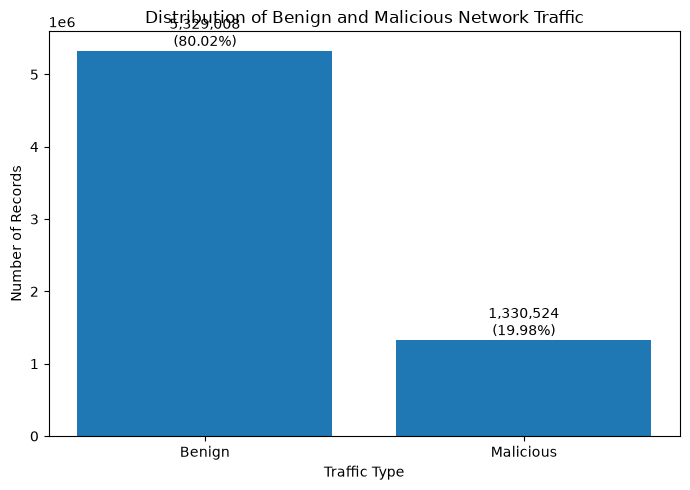

Figure saved to: D:\Sami Data Set\outputs\figures\binary_class_distribution.png


In [4]:
plt.figure(figsize=(7, 5))

plt.bar(
    binary_distribution["traffic_type"],
    binary_distribution["count"]
)

plt.title("Distribution of Benign and Malicious Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")

for index, row in binary_distribution.iterrows():
    plt.text(
        index,
        row["count"],
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

binary_figure_path = (
    FIGURES_DIR / "binary_class_distribution.png"
)

plt.savefig(binary_figure_path, dpi=300)
plt.show()
plt.close()

print("Figure saved to:", binary_figure_path)



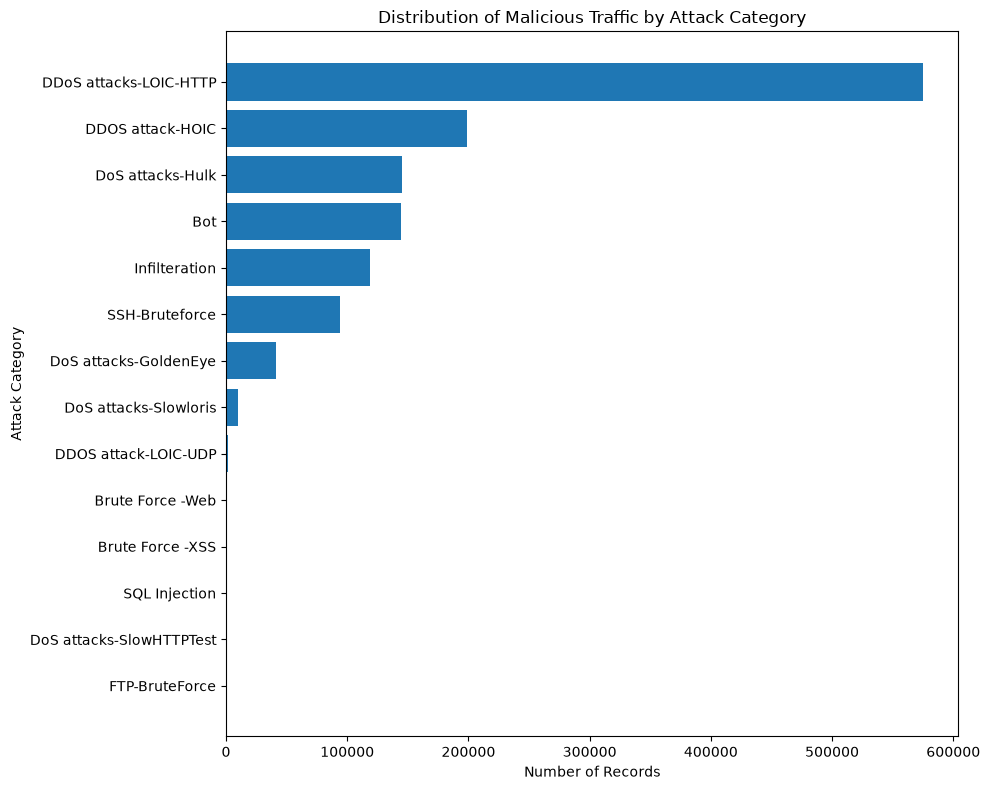

Figure saved to: D:\Sami Data Set\outputs\figures\attack_class_distribution.png


In [5]:
attack_only = attack_distribution[
    attack_distribution["original_attack_label"]
    .str.casefold()
    .ne("benign")
].copy()

attack_only = attack_only.sort_values(
    "count",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    attack_only["original_attack_label"],
    attack_only["count"]
)

plt.title("Distribution of Malicious Traffic by Attack Category")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")

plt.tight_layout()

attack_figure_path = (
    FIGURES_DIR / "attack_class_distribution.png"
)

plt.savefig(
    attack_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Figure saved to:", attack_figure_path)

In [6]:
schema_columns = pq.ParquetFile(
    processed_files[0]
).schema.names

excluded_columns = {
    "original_attack_label",
    "binary_label",
    "source_file_id",
    "source_row_id"
}

candidate_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Fwd Packets Length Total",
    "Bwd Packets Length Total",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "ACK Flag Count"
]

eda_features = [
    column
    for column in candidate_features
    if column in schema_columns
    and column not in excluded_columns
]

print("EDA features found:", len(eda_features))

for feature in eda_features:
    print("-", feature)
    
    

EDA features found: 13
- Flow Duration
- Total Fwd Packets
- Total Backward Packets
- Fwd Packets Length Total
- Bwd Packets Length Total
- Fwd Packet Length Mean
- Bwd Packet Length Mean
- Flow Bytes/s
- Flow Packets/s
- Packet Length Mean
- Packet Length Std
- SYN Flag Count
- ACK Flag Count


In [7]:
sample_parts = []
records_per_class_per_file = 10_000

sample_columns = (
    eda_features
    + [
        "original_attack_label",
        "binary_label",
        "source_file_id"
    ]
)

for file_number, file_path in enumerate(
    processed_files,
    start=1
):
    print(
        f"[{file_number}/{len(processed_files)}] "
        f"Sampling {file_path.name}",
        flush=True
    )

    df = pd.read_parquet(
        file_path,
        columns=sample_columns
    )

    for binary_value in [0, 1]:
        class_data = df[
            df["binary_label"] == binary_value
        ]

        sample_size = min(
            records_per_class_per_file,
            len(class_data)
        )

        if sample_size > 0:
            sampled_data = class_data.sample(
                n=sample_size,
                random_state=(
                    42
                    + file_number * 10
                    + binary_value
                )
            )

            sample_parts.append(sampled_data)

    del df
    gc.collect()

eda_sample = pd.concat(
    sample_parts,
    ignore_index=True
)

eda_sample_path = (
    INTERIM_DIR / "eda_sample.parquet"
)

eda_sample.to_parquet(
    eda_sample_path,
    index=False
)

print("\nEDA sample rows:", f"{len(eda_sample):,}")
print("EDA sample saved to:", eda_sample_path)

display(
    eda_sample["binary_label"]
    .value_counts()
    .rename_axis("binary_label")
    .reset_index(name="count")
)


[1/10] Sampling Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_processed.parquet
[2/10] Sampling Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[3/10] Sampling DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[4/10] Sampling DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[5/10] Sampling DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[6/10] Sampling DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[7/10] Sampling Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[8/10] Sampling Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter_processed.parquet
[9/10] Sampling Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter_processed.parquet
[10/10] Sampling Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter_processed.parquet

EDA sample rows: 180,882
EDA sample saved to: D:\Sami Data Set\data\interim\eda_sample.parquet


,binary_label,count
0,0,100000
1,1,80882


In [ ]:
descriptive_statistics = (
    eda_sample[eda_features]
    .describe(
        percentiles=[
            0.01,
            0.25,
            0.50,
            0.75,
            0.99
        ]
    )
    .transpose()
)

descriptive_statistics.index.name = "feature"
descriptive_statistics = (
    descriptive_statistics.reset_index()
)

display(descriptive_statistics)

descriptive_statistics.to_csv(
    TABLES_DIR / "eda_descriptive_statistics.csv",
    index=False
)


In [8]:
feature_summary_by_class = (
    eda_sample
    .groupby("binary_label")[eda_features]
    .agg(["mean", "median", "std"])
)

display(feature_summary_by_class)

feature_summary_by_class.to_csv(
    TABLES_DIR / "feature_summary_by_binary_class.csv"
)



Flow Duration                         Total Fwd Packets         \
                      mean    median           std              mean median   
binary_label                                                                  
0             7.742213e+06  342252.0  2.619339e+09          8.517970    5.0   
1             8.897649e+06  110263.0  2.507748e+07        171.144284    3.0   

                          Total Backward Packets                     \
                      std                   mean median         std   
binary_label                                                          
0              391.432992               9.637280    2.0  263.283495   
1             4616.743312               5.864815    4.0   20.908935   

             Fwd Packets Length Total  ... Packet Length Mean  \
                                 mean  ...                std   
binary_label                           ...                      
0                         2024.611150  ...         113.990639   
1                         5949.068656  ...          85.759689   

             Packet Length Std                         SYN Flag Count         \
                          mean      median         std           mean median   
binary_label                                                                   
0                   180.945877  109.533218  172.278763       0.039710    0.0   
1                   157.833176  115.406654  150.713699       0.025049    0.0   

                       ACK Flag Count                   
                   std           mean median       std  
binary_label                                            
0             0.195278       0.261060    0.0  0.439215  
1             0.156274       0.288569    0.0  0.453100  

[2 rows x 39 columns]

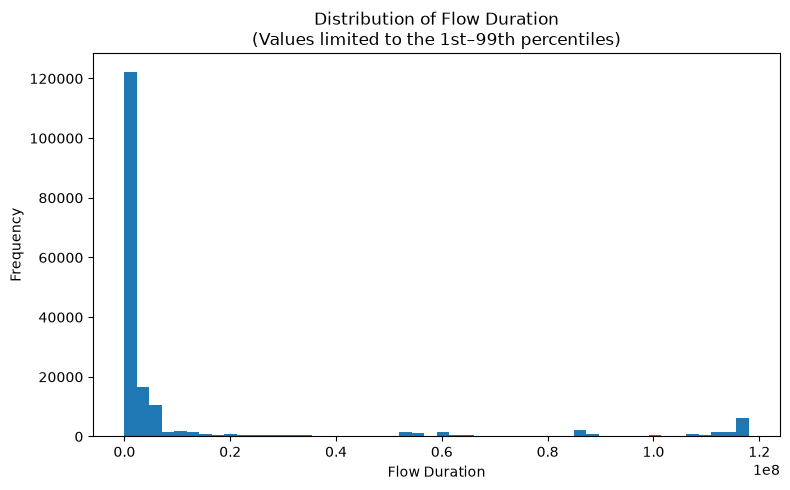

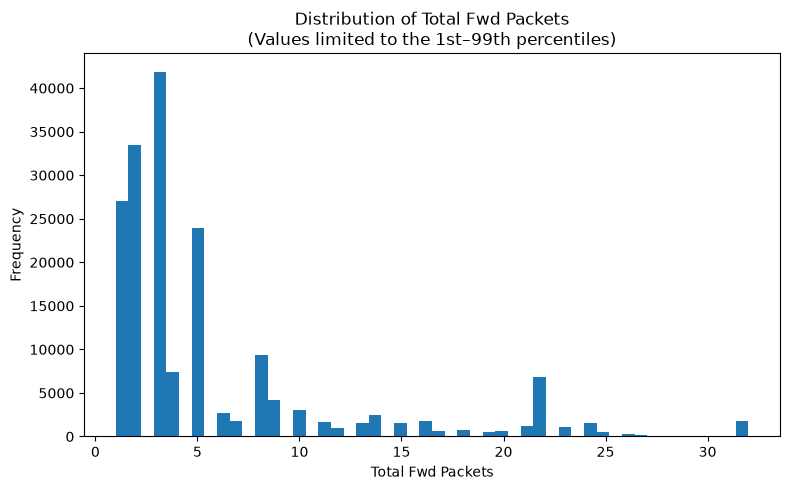

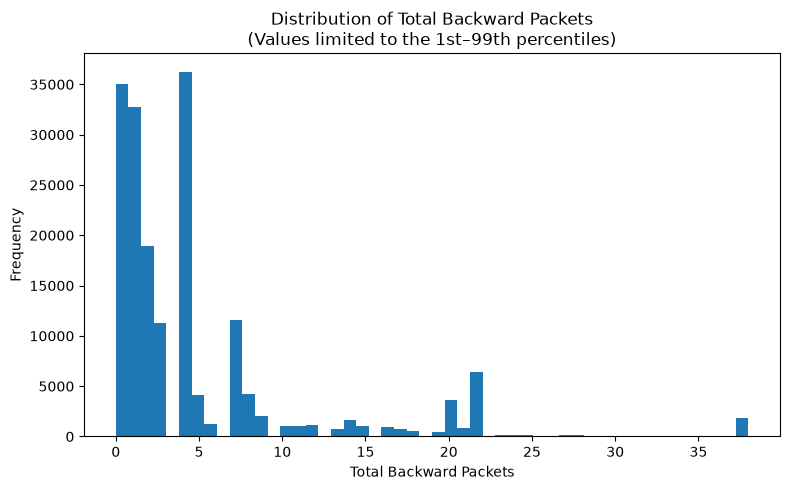

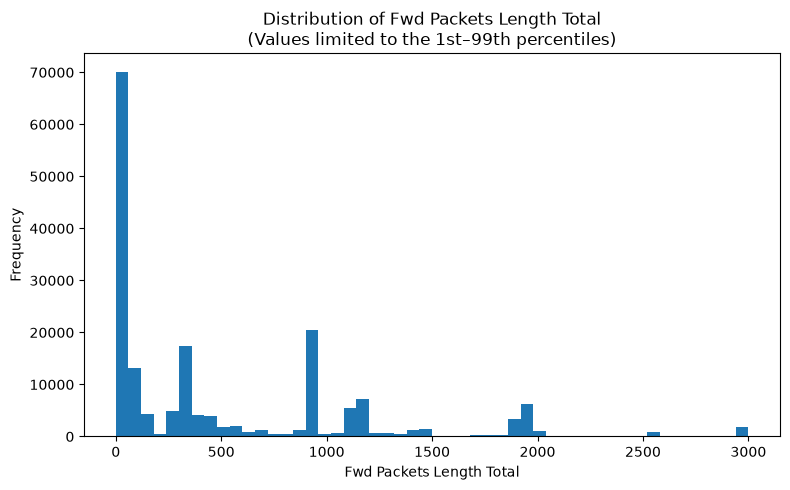

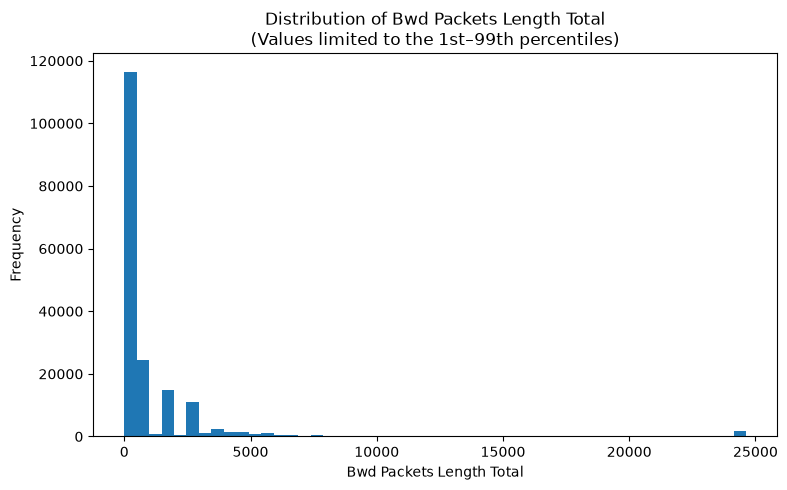

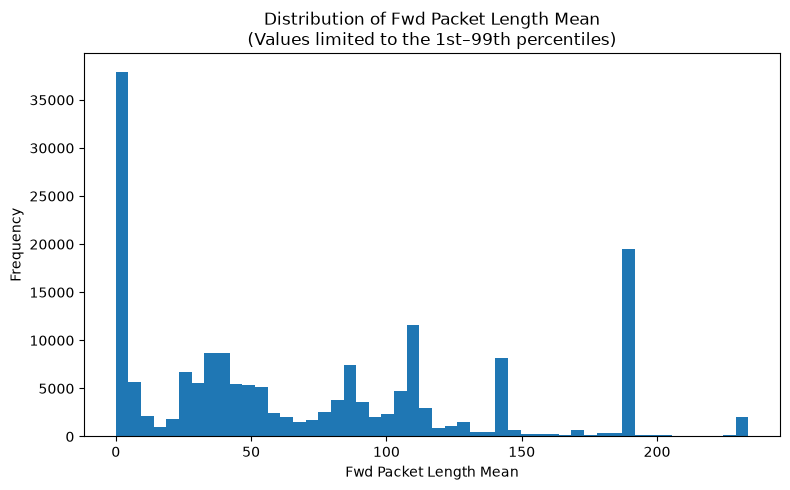

In [9]:
features_for_histograms = eda_features[:6]

for feature in features_for_histograms:
    feature_values = pd.to_numeric(
        eda_sample[feature],
        errors="coerce"
    ).dropna()

    if feature_values.empty:
        continue

    lower_limit = feature_values.quantile(0.01)
    upper_limit = feature_values.quantile(0.99)

    plot_values = feature_values.clip(
        lower=lower_limit,
        upper=upper_limit
    )

    plt.figure(figsize=(8, 5))
    plt.hist(plot_values, bins=50)

    plt.title(
        f"Distribution of {feature}\n"
        "(Values limited to the 1st–99th percentiles)"
    )
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()

    safe_name = (
        feature.lower()
        .replace("/", "_")
        .replace(" ", "_")
    )

    output_path = (
        FIGURES_DIR
        / f"histogram_{safe_name}.png"
    )

    plt.savefig(output_path, dpi=300)
    plt.show()
    plt.close()
    

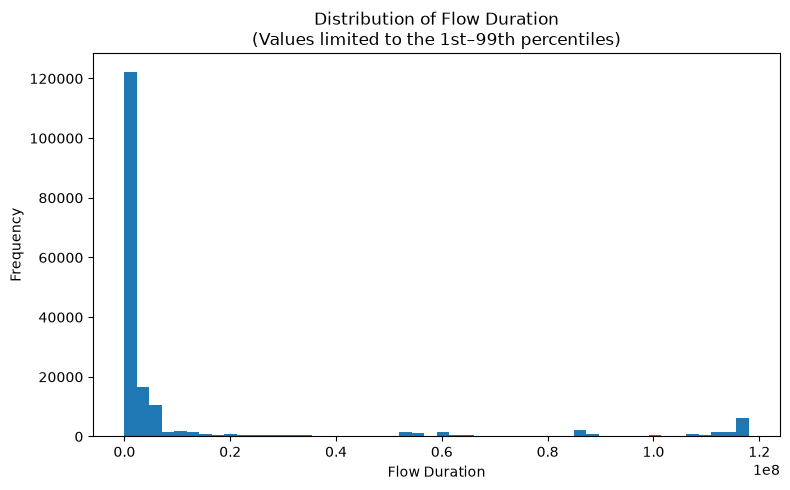

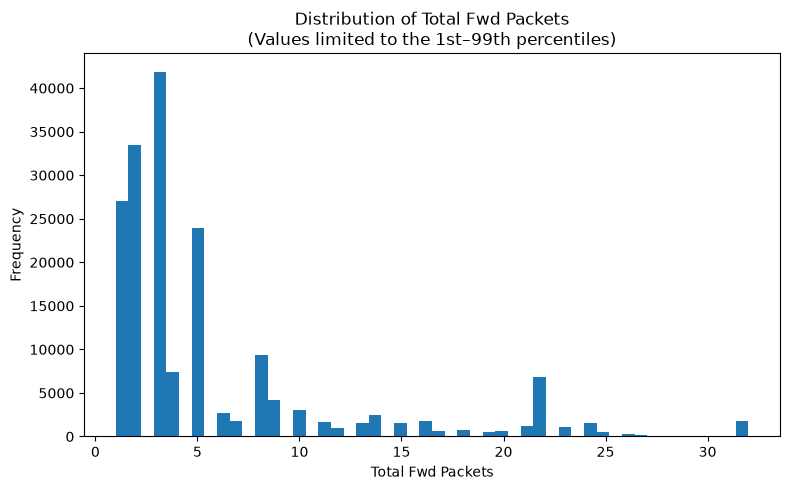

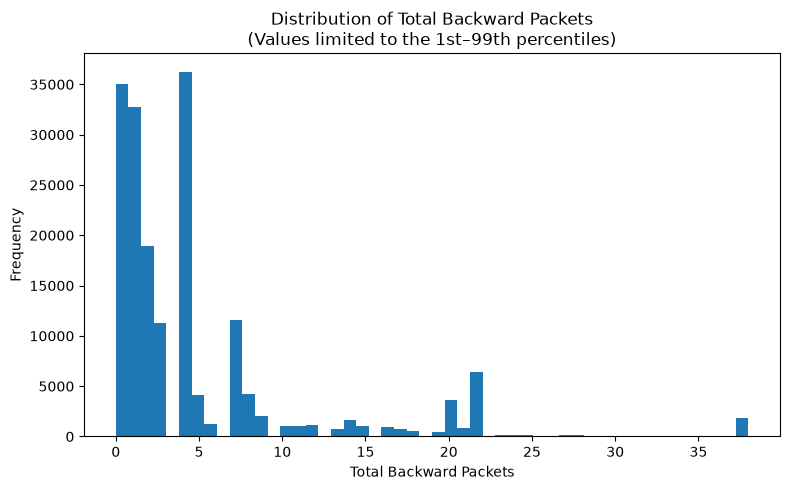

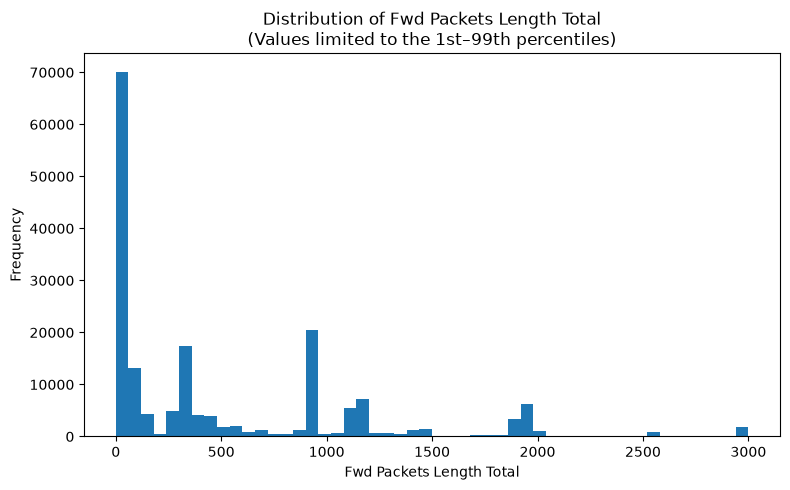

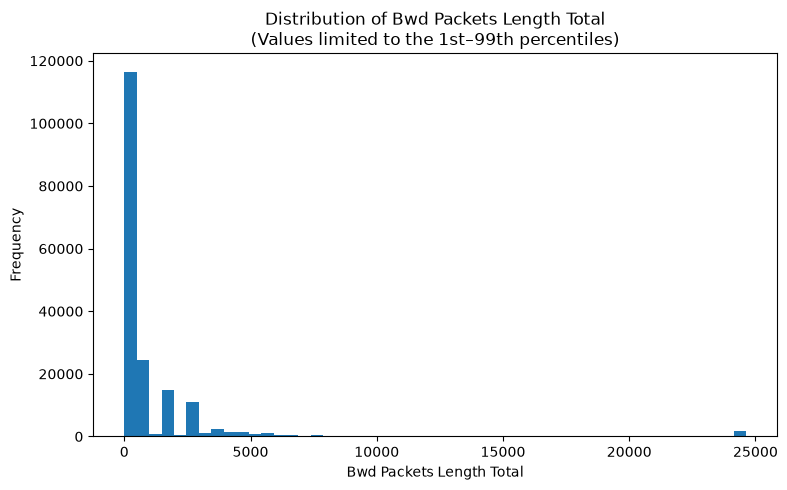

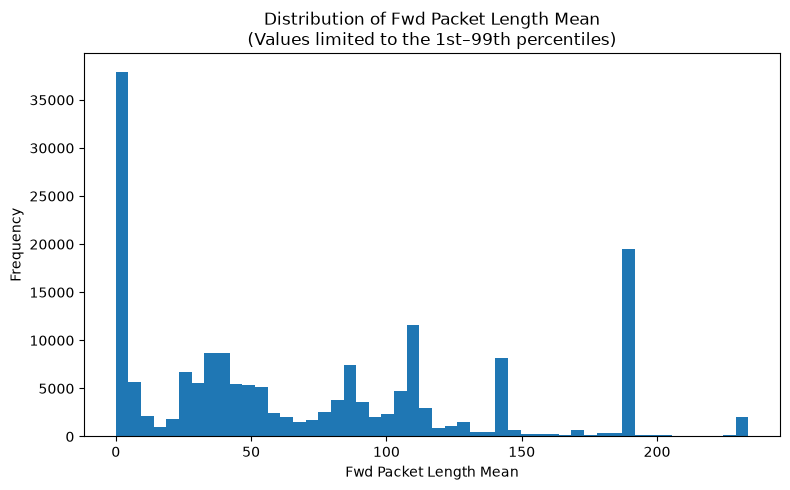

In [10]:
features_for_histograms = eda_features[:6]

for feature in features_for_histograms:
    feature_values = pd.to_numeric(
        eda_sample[feature],
        errors="coerce"
    ).dropna()

    if feature_values.empty:
        continue

    lower_limit = feature_values.quantile(0.01)
    upper_limit = feature_values.quantile(0.99)

    plot_values = feature_values.clip(
        lower=lower_limit,
        upper=upper_limit
    )

    plt.figure(figsize=(8, 5))
    plt.hist(plot_values, bins=50)

    plt.title(
        f"Distribution of {feature}\n"
        "(Values limited to the 1st–99th percentiles)"
    )
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()

    safe_name = (
        feature.lower()
        .replace("/", "_")
        .replace(" ", "_")
    )

    output_path = (
        FIGURES_DIR
        / f"histogram_{safe_name}.png"
    )

    plt.savefig(output_path, dpi=300)
    plt.show()
    plt.close()

## Exploratory Data Analysis Conclusion

The full dataset contains 6,659,532 network-flow records. Benign
traffic accounts for approximately 80.02% of the records, while
malicious traffic accounts for approximately 19.98%, producing an
overall benign-to-malicious ratio of approximately four to one.

The original attack-label distribution is considerably more
imbalanced. Several attack categories contain large numbers of
observations, while some web, SQL-injection and brute-force categories
contain very small numbers of records. This demonstrates why binary
accuracy alone cannot provide sufficient evidence of model
effectiveness.

A reproducible sample was created solely for descriptive
visualisation of selected numerical features. This sample will not be
used to train or evaluate the final classifiers. Feature selection and
all model-related preprocessing will be conducted using training data
only.